In [1]:
# %% [0] Instellingen en functies (eerst uitvoeren)
import csv
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


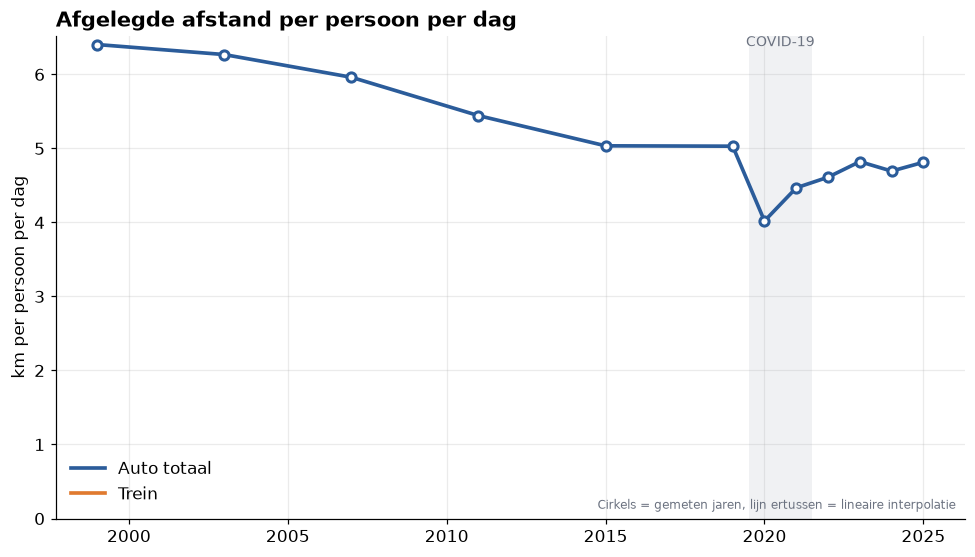

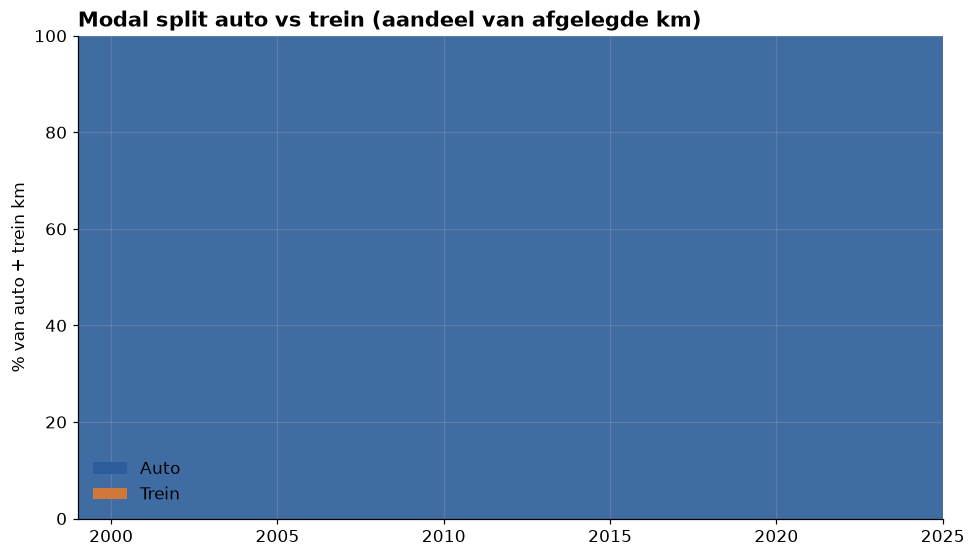

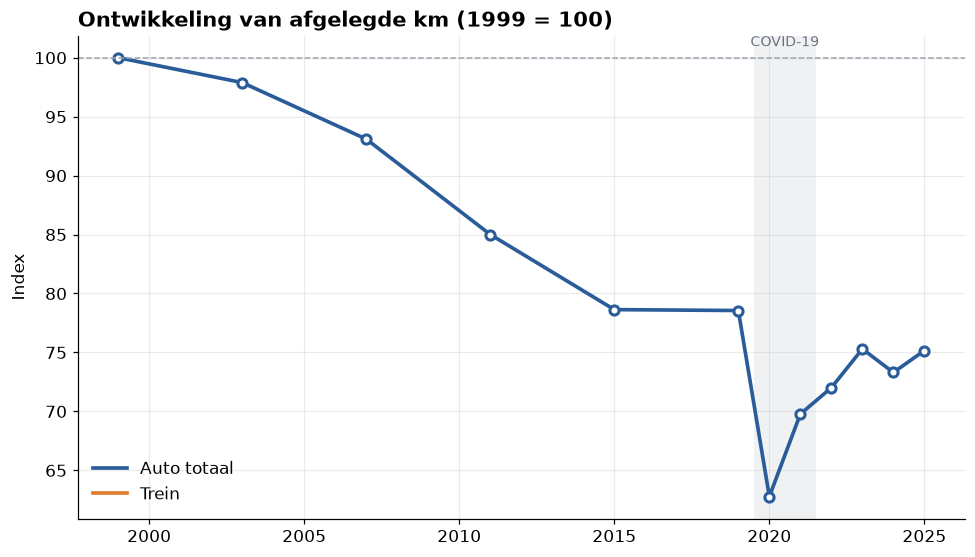

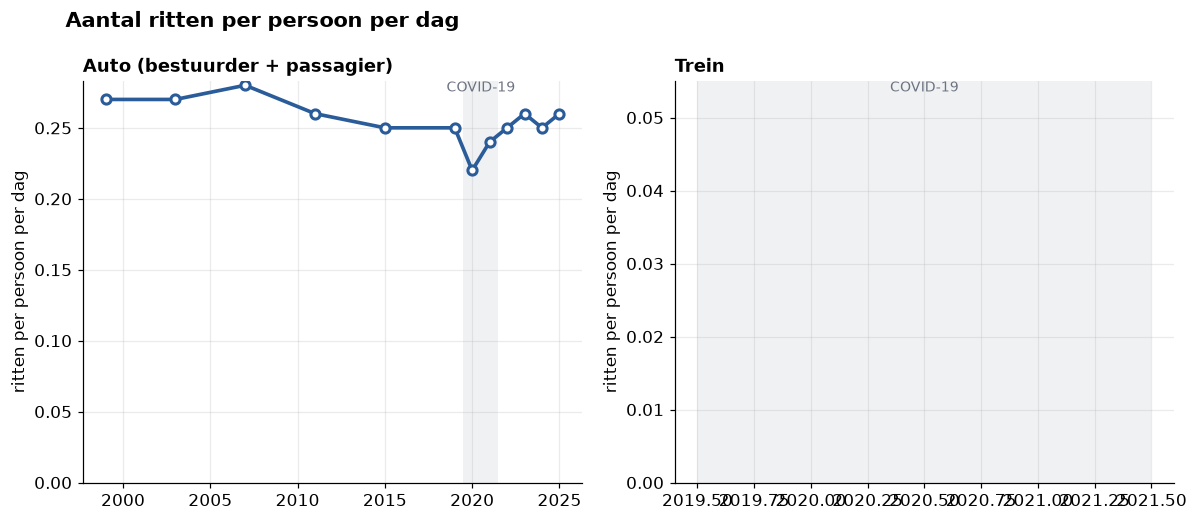

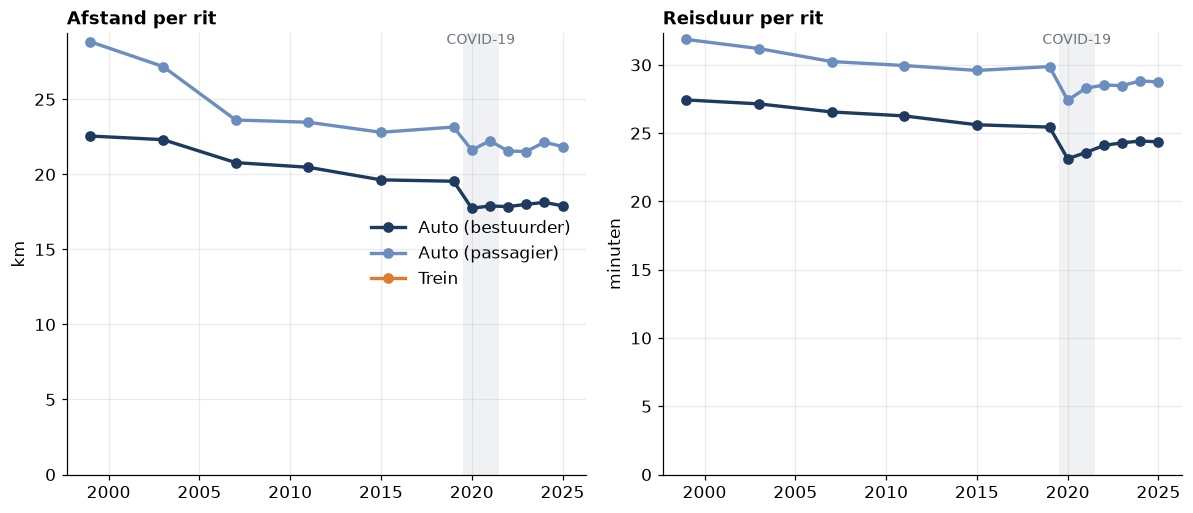

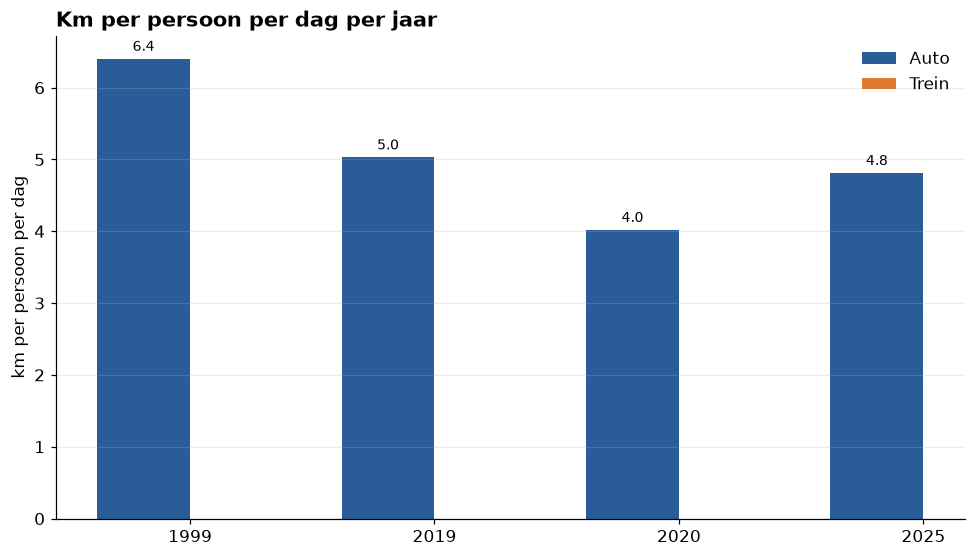

,km_pp_dag_Auto (bestuurder),km_pp_dag_Auto (passagier),km_pp_dag_Trein,km_pp_dag_Auto totaal,aandeel_pct_Auto totaal,aandeel_pct_Trein
jaar,,,,,,
1999,4.96,1.44,NaN,6.40,100.0,NaN
2000,4.95,1.42,NaN,6.37,100.0,NaN
2001,4.93,1.40,NaN,6.33,100.0,NaN
2002,4.92,1.38,NaN,6.30,100.0,NaN
2003,4.91,1.36,NaN,6.27,100.0,NaN
2004,4.88,1.31,NaN,6.19,100.0,NaN
2005,4.84,1.27,NaN,6.11,100.0,NaN
2006,4.81,1.23,NaN,6.04,100.0,NaN
2007,4.78,1.18,NaN,5.96,100.0,NaN


In [7]:
BESTAND = Path(r"C:\Users\Hidde Okhuijsen\Downloads\84755NED_TabelIndeling_20261005100425.csv")
UITVOER = Path("grafieken")
KLEUREN = {
    "Auto (bestuurder)": "#1F3A5F",
    "Auto (passagier)": "#6C8EBF",
    "Auto totaal": "#2B5C9A",
    "Trein": "#E07A2F",
    "Totaal": "#6B7280",
}
COVID = (2020, 2021)

plt.rcParams.update({
    "figure.figsize": (9, 5.2), "figure.dpi": 110, "savefig.dpi": 200,
    "font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold",
    "axes.titlesize": 14, "axes.titlelocation": "left",
})


def naar_getal(x):
    x = x.strip().replace(",", ".")
    try:
        return float(x)
    except ValueError:      # bv. "." of "" van CBS = geen waarde
        return float("nan")


def lees_cbs(pad):
    with open(pad, encoding="utf-8-sig") as f:
        rijen = list(csv.reader(f, delimiter=";"))
    vervoer, onderwerp = rijen[4][3:], rijen[5][3:]
    naam = {
        "Ritten per persoon per dag (gemiddeld)": "ritten",
        "Afgelegde afstand per rit (gemiddeld)": "km_per_rit",
        "Reisduur per rit": "min_per_rit",
    }
    kolommen = [(v, naam[o]) for v, o in zip(vervoer, onderwerp)]
    data = {}
    for r in rijen:
        if r and re.match(r"^\d{4}", r[0]):
            data[int(r[0][:4])] = [naar_getal(x) for x in r[3:]]
    df = pd.DataFrame.from_dict(data, orient="index", columns=pd.MultiIndex.from_tuples(kolommen))
    df.index.name = "jaar"
    return df.sort_index().dropna(how="all")   # jaren zonder enige data weg


def maak_dataset(df):
    modes = ["Auto (bestuurder)", "Auto (passagier)", "Trein"]
    km = pd.DataFrame({m: df[(m, "ritten")] * df[(m, "km_per_rit")] for m in modes})
    km["Auto totaal"] = km["Auto (bestuurder)"] + km["Auto (passagier)"]
    ritten = pd.DataFrame({m: df[(m, "ritten")] for m in modes})
    ritten["Auto totaal"] = ritten["Auto (bestuurder)"] + ritten["Auto (passagier)"]
    jaren = range(df.index.min(), df.index.max() + 1)
    return (km, km.reindex(jaren).interpolate(method="linear", limit_area="inside"),
        ritten, ritten.reindex(jaren).interpolate(method="linear", limit_area="inside"))


def covid_band(ax):
    ax.axvspan(COVID[0] - 0.5, COVID[1] + 0.5, color="#9CA3AF", alpha=0.15, lw=0)
    ax.text(sum(COVID) / 2, ax.get_ylim()[1], "COVID-19", ha="center", va="top",
            fontsize=9, color="#6B7280")


def opslaan(fig, naam):
    UITVOER.mkdir(exist_ok=True)
    fig.tight_layout()
    fig.savefig(UITVOER / f"{naam}.png", bbox_inches="tight")


def lijn(ax, serie, label, orig_index=None):
    kleur = KLEUREN[label]
    ax.plot(serie.index, serie.values, color=kleur, lw=2.4, label=label)
    if orig_index is not None:
        ax.plot(orig_index, serie.loc[orig_index], "o", color=kleur, ms=6, mfc="white", mew=2)


# %% [1] Data inlezen (daarna kun je elke grafiek los draaien)
df = lees_cbs(BESTAND)
km, km_vol, ritten, ritten_vol = maak_dataset(df)
km_vol.round(2)


# %% [2] Grafiek 1: km per persoon per dag
fig, ax = plt.subplots()
for m in ["Auto totaal", "Trein"]:
    lijn(ax, km_vol[m], m, km.index)
ax.set_title("Afgelegde afstand per persoon per dag")
ax.set_ylabel("km per persoon per dag")
ax.set_ylim(0)
ax.legend(frameon=False)
covid_band(ax)
ax.text(0.99, 0.02, "Cirkels = gemeten jaren, lijn ertussen = lineaire interpolatie",
        transform=ax.transAxes, ha="right", fontsize=8, color="#6B7280")
opslaan(fig, "1_km_per_persoon_per_dag")
plt.show()


# %% [3] Grafiek 2: modal split
tweemodes = km_vol[["Auto totaal", "Trein"]]
aandeel = tweemodes.div(tweemodes.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots()
ax.stackplot(aandeel.index, aandeel["Auto totaal"], aandeel["Trein"],
             labels=["Auto", "Trein"],
             colors=[KLEUREN["Auto totaal"], KLEUREN["Trein"]], alpha=0.9)
ax.set_title("Modal split auto vs trein (aandeel van afgelegde km)")
ax.set_ylabel("% van auto + trein km")
ax.set_ylim(0, 100)
ax.set_xlim(aandeel.index.min(), aandeel.index.max())
ax.legend(loc="lower left", frameon=False)
opslaan(fig, "2_modal_split")
plt.show()


# %% [4] Grafiek 3: index (eerste jaar = 100)
idx = km_vol / km_vol.iloc[0] * 100
fig, ax = plt.subplots()
for m in ["Auto totaal", "Trein"]:
    lijn(ax, idx[m], m, km.index)
ax.axhline(100, color="#9CA3AF", lw=1, ls="--")
ax.set_title(f"Ontwikkeling van afgelegde km ({km_vol.index.min()} = 100)")
ax.set_ylabel("Index")
ax.legend(frameon=False)
covid_band(ax)
opslaan(fig, "3_index_km")
plt.show()


# %% [5] Grafiek 4: ritten per persoon per dag
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, m, t in zip(axes, ["Auto totaal", "Trein"], ["Auto (bestuurder + passagier)", "Trein"]):
    lijn(ax, ritten_vol[m], m, ritten.index)
    ax.set_title(t, fontsize=12)
    ax.set_ylim(0)
    ax.set_ylabel("ritten per persoon per dag")
    covid_band(ax)
fig.suptitle("Aantal ritten per persoon per dag", x=0.06, ha="left", fontweight="bold", fontsize=14)
opslaan(fig, "4_ritten_per_dag")
plt.show()


# %% [6] Grafiek 5: afstand en reisduur per rit
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for m in ["Auto (bestuurder)", "Auto (passagier)", "Trein"]:
    axes[0].plot(df.index, df[(m, "km_per_rit")], "o-", color=KLEUREN[m], lw=2.2, label=m)
    axes[1].plot(df.index, df[(m, "min_per_rit")], "o-", color=KLEUREN[m], lw=2.2, label=m)
axes[0].set_title("Afstand per rit", fontsize=12); axes[0].set_ylabel("km")
axes[1].set_title("Reisduur per rit", fontsize=12); axes[1].set_ylabel("minuten")
for ax in axes:
    ax.set_ylim(0)
    covid_band(ax)
axes[0].legend(frameon=False, loc="center right")
opslaan(fig, "5_afstand_en_reisduur_per_rit")
plt.show()


# %% [7] Grafiek 6: vergelijking van vier jaren (pas JAREN gerust aan)
JAREN = [km.index.min(), 2019, 2020, km.index.max()]
sub = km.loc[JAREN, ["Auto totaal", "Trein"]]
fig, ax = plt.subplots()
b = 0.38
x = range(len(JAREN))
b1 = ax.bar([i - b / 2 for i in x], sub["Auto totaal"], b, color=KLEUREN["Auto totaal"], label="Auto")
b2 = ax.bar([i + b / 2 for i in x], sub["Trein"], b, color=KLEUREN["Trein"], label="Trein")
ax.bar_label(b1, fmt="%.1f", padding=3, fontsize=9)
ax.bar_label(b2, fmt="%.1f", padding=3, fontsize=9)
ax.set_xticks(list(x), JAREN)
ax.set_title("Km per persoon per dag per jaar")
ax.set_ylabel("km per persoon per dag")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False)
opslaan(fig, "6_vergelijking_jaren")
plt.show()


# %% [8] Export voor je project (km + modal split per jaar, om met CPI te mergen)
tweemodes = km_vol[["Auto totaal", "Trein"]]
aandeel = tweemodes.div(tweemodes.sum(axis=1), axis=0) * 100
UITVOER.mkdir(exist_ok=True)
uit = km_vol.add_prefix("km_pp_dag_").join(aandeel.add_prefix("aandeel_pct_"))
uit.to_csv(UITVOER / "modal_split_per_jaar.csv", sep=";", decimal=",")
uit.round(2)